In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('/content/drive/MyDrive/sentiment_tweets3 (1).csv')
df

,Index,message to examine,label (depression result)
0,106,just had a real good moment. i missssssssss hi...,0
1,217,is reading manga http://plurk.com/p/mzp1e,0
2,220,@comeagainjen http://twitpic.com/2y2lx - http:...,0
3,288,@lapcat Need to send 'em to my accountant tomo...,0
4,540,ADD ME ON MYSPACE!!! myspace.com/LookThunder,0
...,...,...,...
10309,802309,No Depression by G Herbo is my mood from now o...,1
10310,802310,What do you do when depression succumbs the br...,1
10311,802311,Ketamine Nasal Spray Shows Promise Against Dep...,1
10312,802312,dont mistake a bad day with depression! everyo...,1


In [2]:
import pandas as pd
import numpy as np

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10314 entries, 0 to 10313
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Index                      10314 non-null  int64 
 1   message to examine         10314 non-null  object
 2   label (depression result)  10314 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 241.9+ KB


In [4]:
df.head()

,Index,message to examine,label (depression result)
0,106,just had a real good moment. i missssssssss hi...,0
1,217,is reading manga http://plurk.com/p/mzp1e,0
2,220,@comeagainjen http://twitpic.com/2y2lx - http:...,0
3,288,@lapcat Need to send 'em to my accountant tomo...,0
4,540,ADD ME ON MYSPACE!!! myspace.com/LookThunder,0


In [5]:
df.shape

(10314, 3)

In [6]:
df.isna().sum()

,0
Index,0
message to examine,0
label (depression result),0


In [7]:
df.columns

Index(['Index', 'message to examine', 'label (depression result)'], dtype='object')

In [8]:
df['label (depression result)'].value_counts()

,count
label (depression result),
0,8000
1,2314


In [9]:
text=df['message to examine']
type(text)

pandas.core.series.Series

In [10]:
from nltk.stem import SnowballStemmer
from nltk import TweetTokenizer


stemmer=SnowballStemmer('english')
tk=TweetTokenizer()

In [11]:
text=text.apply(lambda x:[stemmer.stem(i.lower())for i in tk.tokenize(x)]).apply(lambda y:" ".join(y))
text

,message to examine
0,just had a real good moment . i missssssssss h...
1,is read manga http://plurk.com/p/mzp1
2,@comeagainjen http://twitpic.com/2y2lx - http:...
3,@lapcat need to send ' em to my account tomorr...
4,add me on myspac ! ! ! myspace.com/lookthund
...,...
10309,"no depress by g herbo is my mood from now on ,..."
10310,what do you do when depress succumb the brain ...
10311,ketamin nasal spray show promis against depres...
10312,dont mistak a bad day with depress ! everyon h...


In [12]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
sw=set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
text=text.apply(lambda x:[i for i in tk.tokenize(x) if i not in sw]).apply(lambda y:" ".join(y))
text

,message to examine
0,"real good moment . missssssssss much ,"
1,read manga http://plurk.com/p/mzp1
2,@comeagainjen http://twitpic.com/2y2lx - http:...
3,@lapcat need send ' em account tomorrow . odd ...
4,add myspac ! ! ! myspace.com/lookthund
...,...
10309,"depress g herbo mood , i'm done stress peopl d..."
10310,depress succumb brain make feel like never eno...
10311,"ketamin nasal spray show promis depress , suic..."
10312,dont mistak bad day depress ! everyon ' em !


In [17]:
text.shape

(10314,)

In [16]:
text

,message to examine
0,"real good moment . missssssssss much ,"
1,read manga http://plurk.com/p/mzp1
2,@comeagainjen http://twitpic.com/2y2lx - http:...
3,@lapcat need send ' em account tomorrow . odd ...
4,add myspac ! ! ! myspace.com/lookthund
...,...
10309,"depress g herbo mood , i'm done stress peopl d..."
10310,depress succumb brain make feel like never eno...
10311,"ketamin nasal spray show promis depress , suic..."
10312,dont mistak bad day depress ! everyon ' em !


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer=TfidfVectorizer()
train_vect=vectorizer.fit_transform(text)
print(train_vect)

  (0, 14533)	0.39208210549027656
  (0, 7461)	0.25918864259609664
  (0, 11869)	0.47667822191043324
  (0, 11753)	0.665397361899697
  (0, 12102)	0.3303287659843387
  (1, 14526)	0.3275823119762473
  (1, 11093)	0.5663417726257799
  (1, 8454)	0.2198241659006373
  (1, 13779)	0.4018886170298152
  (1, 4241)	0.20338804691138346
  (1, 12243)	0.5663417726257799
  (2, 8454)	0.33357656719521417
  (2, 4241)	0.30863525044787526
  (2, 4248)	0.3985092218521677
  (2, 18050)	0.24360609830144897
  (2, 455)	0.4297033121853243
  (2, 19238)	0.2103020797240635
  (2, 19526)	0.34546555167838705
  (2, 18737)	0.20604402400837468
  (2, 19659)	0.4297033121853243
  (3, 10235)	0.37783239227067217
  (3, 12386)	0.19200982256184648
  (3, 15581)	0.2546273855639871
  (3, 5998)	0.28874645769199725
  (3, 1212)	0.2811862052477378
  :	:
  (10310, 6570)	0.282712552278031
  (10310, 12449)	0.32844236130981785
  (10310, 6101)	0.3895527402683284
  (10310, 3105)	0.4165703473560067
  (10310, 5153)	0.15659559047536203
  (10310, 16748)

In [19]:
train_vect.shape

(10314, 19731)

In [21]:
x=train_vect
y=df['label (depression result)'].values

In [22]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=0)

#MODEL BULDING

In [23]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [24]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
accuracy

0.979967689822294

In [25]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
svm_model = SVC()
rf_model = RandomForestClassifier()
ada_model = AdaBoostClassifier()

lst_model=[svm_model,rf_model,ada_model]


In [26]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay

In [27]:
print(y_train.shape)
print(y_test.shape)

(7219,)
(3095,)


SVC()
****************************************************************************************************
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2397
           1       1.00      0.96      0.98       698

    accuracy                           0.99      3095
   macro avg       0.99      0.98      0.99      3095
weighted avg       0.99      0.99      0.99      3095

****************************************************************************************************
RandomForestClassifier()
****************************************************************************************************
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2397
           1       1.00      0.99      0.99       698

    accuracy                           1.00      3095
   macro avg       1.00      1.00      1.00      3095
weighted avg       1.00      1.00      1.00      3095

************

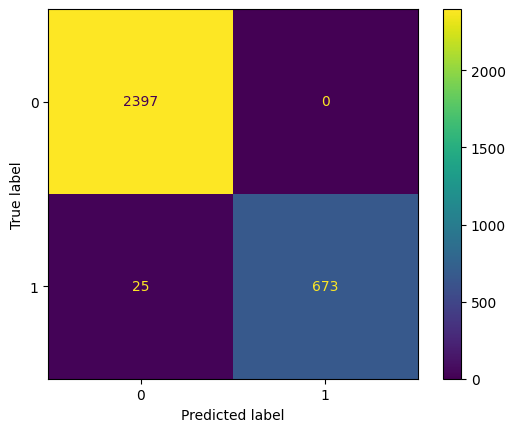

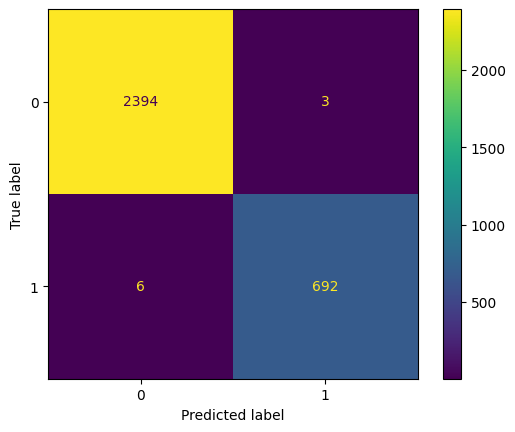

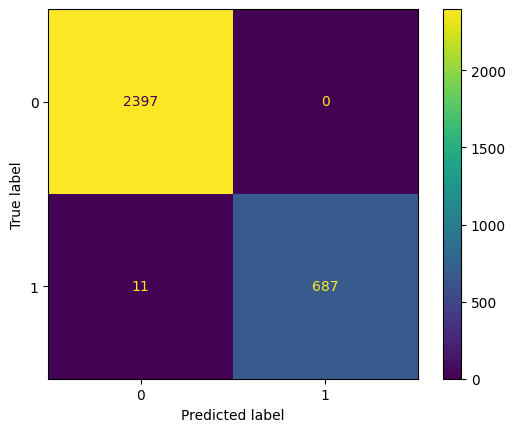

In [28]:
for i in lst_model:
  print(i)
  i.fit(x_train,y_train)
  y_predict=i.predict(x_test)
  print('*'*100)
  print(classification_report(y_test,y_predict))
  print('*'*100)
  print(ConfusionMatrixDisplay.from_predictions(y_test,y_predict))
